# Phase 2: Seed sweep (fixed schedule) — Colab

**目的**: ローカルのパイロット学習で、$V_{max}(t)=F(t)/k(t)$ の収束先が学習ごとに大きくばらついた(約30〜40)。エポック数などのスケジュールを揃えずにseedだけ変えていたため、「学習不足」と「本質的な識別不能性」のどちらが原因か切り分けられていなかった。このノートブックは**スケジュールを固定してseedだけを複数試し**、どちらが正しいかを確認する。

詳細: `documents/phase2_pilot_results.md`、実行するロジックは `scripts/phase2_seed_sweep.py`。

**判定基準**: seed間の $V_{max}$ プラトーの変動係数(CV) が10%未満なら「収束していた、スケジュールの問題だった」、それ以上なら「まだ不安定=識別性に課題が残る」。

**実行前に**: メニューの `ランタイム > ランタイムのタイプを変更` で **GPU** を選択してください。

## 1. Google Drive をマウント(結果の永続化用)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUT_DIR = '/content/drive/MyDrive/pi-fsm/phase2_seed_sweep'
import os
os.makedirs(OUT_DIR, exist_ok=True)
print('results will be saved to', OUT_DIR)

## 2. リポジトリを取得

既にcloneしてあれば `git pull` で最新化する。特定のコミット/タグに固定したい場合は `git checkout <tag>` を追加。

In [6]:
%cd /content
if not os.path.exists('/content/pi-fsm'):
    !git clone https://github.com/ryu622/pi-fsm.git
%cd /content/pi-fsm
!git pull
!git log --oneline -5

/content
/content/pi-fsm
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 2.04 KiB | 260.00 KiB/s, done.
From https://github.com/ryu622/pi-fsm
   55e8358..9d38a7f  main       -> origin/main
Updating 55e8358..9d38a7f
Fast-forward
 notebooks/colab_seed_sweep.ipynb | 50 +++++++++++++++++++++++++++++++++++-----
 scripts/phase2_seed_sweep.py     | 11 +++++++--
 2 files changed, 53 insertions(+), 8 deletions(-)
9d38a7f (HEAD -> main, origin/main, origin/HEAD) Add v0-range x short-segment combined experiment for seed sweep
55e8358 Add Colab seed-sweep notebook for phase 2 identifiability check
99e2425 Initial commit: pi-fsm research project through phase 2 pilot


## 3. 依存関係のインストール

Colabには torch/numpy/pandas/matplotlib/scipy は概ね入っているが、`kloppy`, `mplsoccer`, `pyarrow` 等は入っていないことが多い。`pip install -e .` で `pyproject.toml` の依存関係を一括インストールする(数分かかることがある)。

In [ ]:
!pip install -q -e .

import torch
print('torch', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU detected — go to ランタイム > ランタイムのタイプを変更 > GPU')

## 4. Seedスウィープ実行

1試合(J03WPY)、固定スケジュール、5 seed。GPUなら1seedあたり数分程度の見込み(ローカルCPU/MPSでは8〜30分かかっていた)。

In [7]:
!python scripts/phase2_seed_sweep.py --match-id J03WPY --seeds 0,1,2,3,4 --out-dir "{OUT_DIR}"

J03WPY (v_low=2.0): 1332 segments (t<=2.5s), 76346 rows, v0_max=2.00
schedule: {'epochs': 10000, 'lr': 0.003, 'lr_min_factor': 0.05, 'gamma_final': 5.0, 'gamma_warmup_epochs': 2000, 'n_colloc': 1500, 'traj_hidden': 128, 'traj_n_hidden': 5}
seeds: [0, 1, 2, 3, 4]
Traceback (most recent call last):
  File "/content/pi-fsm/scripts/phase2_seed_sweep.py", line 178, in <module>
    main()
  File "/content/pi-fsm/scripts/phase2_seed_sweep.py", line 124, in main
    results = [run_one_seed(segs, v0_max, seed, out_dir) for seed in seeds]
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/pi-fsm/scripts/phase2_seed_sweep.py", line 61, in run_one_seed
    res = train_pinn(segs, config)
          ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/pi-fsm/src/pi_fsm/pinn/train.py", line 108, in train_pinn
    loss, l_data, l_phys = total_loss(
                           ^^^^^^^^^^^
  File "/content/pi-fsm/src/pi_fsm/pinn/loss.py", line 86, in total_loss
    l_phys = physics_loss(traj_n

## 5. 結果の確認

In [ ]:
import json
from IPython.display import Image, display

with open(f'{OUT_DIR}/summary.json') as f:
    summary = json.load(f)

print(f"Vmax plateau: mean={summary['vmax_plateau_mean']:.2f}, std={summary['vmax_plateau_std']:.2f}, cv={summary['vmax_plateau_cv']:.1%}")
print('Baseline1 (dt=1s) reference: Vmax=12.34')
verdict = '収束していた(スケジュールの問題だった)' if summary['vmax_plateau_cv'] < 0.10 else 'まだ不安定(識別性の課題が残る)'
print('判定:', verdict)

display(Image(f'{OUT_DIR}/seed_sweep_summary.png'))

## 次のステップ

- **CV<10%の場合**: スケジュール(エポック数・学習率)の問題だったと確定。あとはBaseline1との倍率のズレ(前回2.4倍)の原因を追う
- **CV>=10%の場合**: 識別性の課題が本質的に残っている。$v_0$ レンジを広げる(区間の開始条件を緩める)ことと短区間制限を**両方同時に**試す、あるいは選手embeddingなどの追加の条件付けを検討する
- 結果一式(`summary.json`, `seed_*.json`, 図)はDriveの `{OUT_DIR}` に永続化されているので、Colabセッションが切れても失われない

## 6. 追加実験: v0レンジを広げて同時に試す(CV>=10%だった場合)

結果: **CV=31.8%(mean=47.09, std=14.99)— 識別性の課題が残っていることを確認**。

以前 $v_0$ レンジを広げる実験(`v_low`=2.0→6.0)は単独では効果がなかったが、その時は区間を短く絞る前だった(まだ$\mathcal{L}_{data}$が収束していない設定と混ざっていた)。今度は**短区間制限(t≤2.5s、既に組み込み済み)と広い$v_0$レンジを同時に**試す。`--v-low` オプションで区間開始条件を緩める。

まず新しいセルをこのノートブックに追加して(下のコードをコピー)実行:

In [8]:
%cd /content/pi-fsm
!git pull

OUT_DIR_WIDE = '/content/drive/MyDrive/pi-fsm/phase2_seed_sweep_wide_v0'
!python scripts/phase2_seed_sweep.py --match-id J03WPY --seeds 0,1,2,3,4 --v-low 6.0 --out-dir "{OUT_DIR_WIDE}"

/content/pi-fsm
Already up to date.
J03WPY (v_low=6.0): 1597 segments (t<=2.5s), 89867 rows, v0_max=4.95
schedule: {'epochs': 10000, 'lr': 0.003, 'lr_min_factor': 0.05, 'gamma_final': 5.0, 'gamma_warmup_epochs': 2000, 'n_colloc': 1500, 'traj_hidden': 128, 'traj_n_hidden': 5}
seeds: [0, 1, 2, 3, 4]
seed=0: 299s on cuda, L_data=1.0137, Vmax_plateau=16.54
seed=1: 296s on cuda, L_data=1.0136, Vmax_plateau=51.70
seed=2: 294s on cuda, L_data=1.0136, Vmax_plateau=22.91
seed=3: 310s on cuda, L_data=1.0132, Vmax_plateau=66.38
seed=4: 308s on cuda, L_data=1.0114, Vmax_plateau=54.03

Vmax plateau across seeds: mean=42.31, std=19.21, cv=45.4%
L_data across seeds: mean=1.0131, std=0.0008
VERDICT: still unstable (likely a genuine identifiability gap)
saved /content/drive/MyDrive/pi-fsm/phase2_seed_sweep_wide_v0/seed_sweep_summary.png
saved /content/drive/MyDrive/pi-fsm/phase2_seed_sweep_wide_v0/summary.json


[wide v0] Vmax plateau: mean=42.31, std=19.21, cv=45.4%
[narrow v0, previous] cv=31.8%
Baseline1 (dt=1s) reference: Vmax=12.34
判定: 改善しなかった(v0レンジは主因ではない)


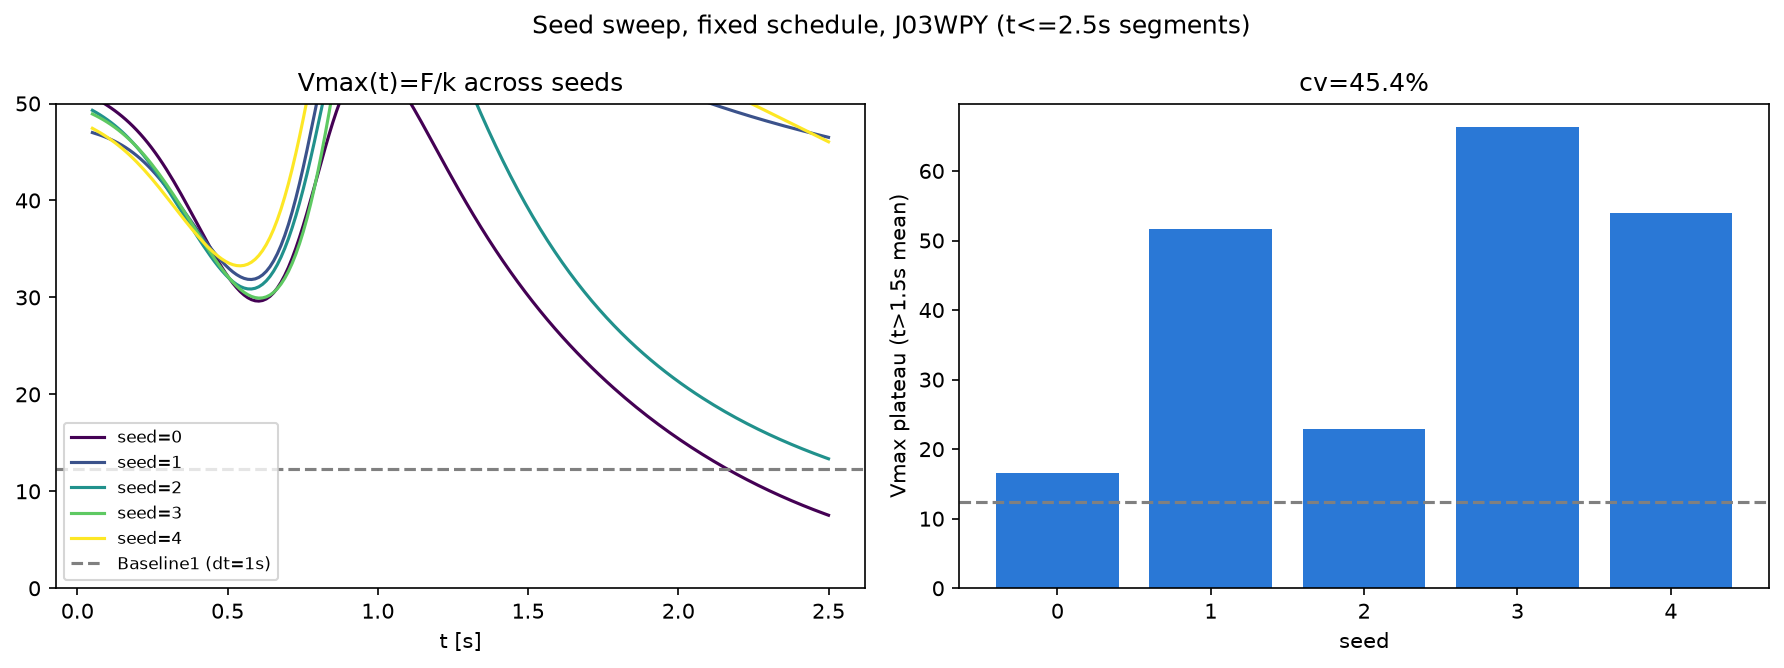

In [9]:
with open(f'{OUT_DIR_WIDE}/summary.json') as f:
    summary_wide = json.load(f)

print(f"[wide v0] Vmax plateau: mean={summary_wide['vmax_plateau_mean']:.2f}, std={summary_wide['vmax_plateau_std']:.2f}, cv={summary_wide['vmax_plateau_cv']:.1%}")
print(f"[narrow v0, previous] cv={summary['vmax_plateau_cv']:.1%}")
print('Baseline1 (dt=1s) reference: Vmax=12.34')
verdict_wide = '改善した(v0多様性が効いていた)' if summary_wide['vmax_plateau_cv'] < summary['vmax_plateau_cv'] * 0.7 else '改善しなかった(v0レンジは主因ではない)'
print('判定:', verdict_wide)

display(Image(f'{OUT_DIR_WIDE}/seed_sweep_summary.png'))